# 🔆 Overview
This notebook imports minute level synthetic data *train_onset_final_0329.csv* and *test_onset_final_0329.csv*, builds the Gradient Boosting model.

Here, we predict the glucose status of current using x minutes data that n-minute ahead of now.

# 🔆 Setup / Import Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
from itertools import product

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.inspection import permutation_importance
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingGridSearchCV

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    make_scorer
)

from xgboost import XGBClassifier

In [ ]:
# mounting on gdrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import data
# WooJung
# data_path = "/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/data_0228"

# Ainsley

# Ci
data_path = "/content/drive/MyDrive/210 Capstone/final_data/updated"

In [ ]:
# import train df: canine 2 - 6
file_train_df = os.path.join(data_path, "train_onset_final_0329.csv")
raw_train_df = pd.read_csv(file_train_df)

raw_train_df.head()

,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,split
0,canine2,canine2-001,2025-04-09 12:56:00,308.000000,hyperglycemia,True,True,False,False,train
1,canine2,canine2-001,2025-04-09 12:57:00,305.615730,hyperglycemia,True,False,False,False,train
2,canine2,canine2-001,2025-04-09 12:58:00,303.471173,hyperglycemia,True,False,False,False,train
3,canine2,canine2-001,2025-04-09 12:59:00,301.876377,hyperglycemia,True,False,False,False,train
4,canine2,canine2-001,2025-04-09 13:00:00,298.388740,hyperglycemia,True,False,False,False,train


In [ ]:
# import test df: canine 1
file_test_df = os.path.join(data_path, "test_onset_final_0329.csv")
raw_test_df = pd.read_csv(file_test_df)

raw_test_df.head()

,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,split
0,canine1,canine1-001,2025-11-01 05:51:00,375.000000,hyperglycemia,True,True,False,False,test
1,canine1,canine1-001,2025-11-01 05:52:00,375.056846,hyperglycemia,True,False,False,False,test
2,canine1,canine1-001,2025-11-01 05:53:00,374.714980,hyperglycemia,True,False,False,False,test
3,canine1,canine1-001,2025-11-01 05:54:00,375.045685,hyperglycemia,True,False,False,False,test
4,canine1,canine1-001,2025-11-01 05:55:00,375.676269,hyperglycemia,True,False,False,False,test


# 🔆 Feature Engineering

Next we're going to build engineered features from a historical window that ends `ahead_minutes` before the target time:

history_minutes=30, ahead_minutes=15

-> use [t-45, t-15) to predict target at t

In [ ]:
def feature_engineering_minute_ahead(
    df,
    history_minutes=30,
    ahead_minutes=15,
    glucose_col="glucose",
    # for multiclass, unsafe is changed to glucose_category
    target_col = "glucose_category",
    dog_col="dogID",
    segment_col="ID",
    time_col="timestamp",
    onset_col="onset"): # Added 'onset_col'
    """
    Build engineered features from minute-level synthetic data.

    For each target time t:
      - use a history window of length `history_minutes`
      - the history window ends `ahead_minutes` before t
      - predict target_col at time t

    Example:
      history_minutes = 30, ahead_minutes = 10
      -> use [t-40, t-10) to predict status at t
    """

    features = []

    # Group by ID so each window stays inside the subset
    for seg_id, group in df.groupby(segment_col, sort=False):
        dog = group[dog_col].iloc[0]

        # Convert needed columns to NumPy arrays for faster slicing
        glucose = group[glucose_col].astype(float).to_numpy()
        timestamps = pd.to_datetime(group[time_col]).to_numpy()
        targets = group[target_col]
        onset_values = group[onset_col]

        n = len(group)

        # Earliest valid target index:
        # we need enough earlier rows to cover both history and ahead gap
        start_i = history_minutes + ahead_minutes

        for i in range(start_i, n):
            # Window layout:
            #   target row = i
            #   history ends at i - ahead_minutes (exclusive)
            hist_end = i - ahead_minutes
            hist_start = hist_end - history_minutes

            # Slice the glucose history window and its timestamps
            g = glucose[hist_start:hist_end]
            ts_window = timestamps[hist_start:hist_end]

            # Summary statistics from the history window
            min_glucose = np.min(g)
            max_glucose = np.max(g)
            first_glucose = g[0]
            last_glucose = g[-1]

            # Unweighted mean of glucose values
            mean_glucose = np.mean(g)

            # Slope feature:
            # overall change across the window, scaled by history_minutes
            slope = (last_glucose - first_glucose) / history_minutes

            # Mean gap between consecutive timestamps in the history window
            # This should be 1 for minute-level synthetic data
            gap_minutes = np.diff(ts_window) / np.timedelta64(1, "m")
            mean_gap = gap_minutes.mean()

            # Number of readings used in this history window
            num_readings = len(g)

            # Store one feature row for this target time t
            features.append({
                segment_col: seg_id,          # subset ID / continuous segment
                dog_col: dog,                 # dog identifier for LODO later
                time_col: timestamps[i],      # target time t

                "history_minutes": history_minutes,
                "ahead_minutes": ahead_minutes,

                "mean_glucose": mean_glucose,
                "min_glucose": min_glucose,
                "max_glucose": max_glucose,
                "slope": slope,
                "last_glucose": last_glucose,
                "mean_gap": mean_gap,
                "num_readings": num_readings,

                # actual glucose level at time t
                "glucose": glucose[i],

                # target at time t
                # changed to accommodate multiclass
                target_col: targets.iloc[i],
                onset_col: onset_values.iloc[i] # Added onset to the output features
            })

    return pd.DataFrame(features)

In [ ]:
# Build one feature table for one setting
train_feat_df = feature_engineering_minute_ahead(
    df=raw_train_df,
    history_minutes=30,
    ahead_minutes=15,
    target_col="glucose_category"
)

test_feat_df = feature_engineering_minute_ahead(
    df=raw_test_df,
    history_minutes=30,
    ahead_minutes=15,
    target_col="glucose_category"
)

In [ ]:
display(train_feat_df.head(3))
train_feat_df[train_feat_df["onset"] == True].head(10)

,ID,dogID,timestamp,history_minutes,ahead_minutes,mean_glucose,min_glucose,max_glucose,slope,last_glucose,mean_gap,num_readings,glucose,glucose_category,onset
0,canine2-001,canine2,2025-04-09 13:41:00,30,15,280.147356,264.476275,308.000000,-1.450791,264.476275,1.0,30,257.000000,hyperglycemia,False
1,canine2-001,canine2,2025-04-09 13:42:00,30,15,278.680689,264.000000,305.615730,-1.387191,264.000000,1.0,30,257.691435,hyperglycemia,False
2,canine2-001,canine2,2025-04-09 13:43:00,30,15,277.287060,263.806835,303.471173,-1.322145,263.806835,1.0,30,259.248454,hyperglycemia,False


,ID,dogID,timestamp,history_minutes,ahead_minutes,mean_glucose,min_glucose,max_glucose,slope,last_glucose,mean_gap,num_readings,glucose,glucose_category,onset
160,canine2-001,canine2,2025-04-09 16:21:00,30,15,204.583951,196.474474,221.025750,0.818376,221.025750,1.0,30,251.053282,hyperglycemia,True
331,canine2-001,canine2,2025-04-09 19:12:00,30,15,243.456340,239.312684,249.936868,-0.312937,240.000000,1.0,30,250.827129,hyperglycemia,True
418,canine2-001,canine2,2025-04-09 20:39:00,30,15,235.356401,223.000000,254.268797,-0.678909,233.901516,1.0,30,250.329193,hyperglycemia,True
478,canine2-001,canine2,2025-04-09 21:39:00,30,15,162.864943,113.696203,220.579200,-3.562767,113.696203,1.0,30,62.332430,hypoglycemia,True
525,canine2-001,canine2,2025-04-09 22:26:00,30,15,70.867666,53.000000,79.835562,0.580108,74.000000,1.0,30,64.585397,hypoglycemia,True
681,canine2-001,canine2,2025-04-10 01:02:00,30,15,208.486334,169.033339,222.432790,1.760468,221.847384,1.0,30,252.110928,hyperglycemia,True
1303,canine2-001,canine2,2025-04-10 11:24:00,30,15,275.514483,248.072112,295.000000,-1.464263,248.072112,1.0,30,250.251004,hyperglycemia,True
1343,canine2-001,canine2,2025-04-10 12:04:00,30,15,246.298308,240.385232,252.000000,-0.223444,240.385232,1.0,30,250.477781,hyperglycemia,True
1391,canine2-001,canine2,2025-04-10 12:52:00,30,15,256.023298,250.673365,264.000000,-0.003792,252.738842,1.0,30,255.000000,hyperglycemia,True
1544,canine2-001,canine2,2025-04-10 15:25:00,30,15,101.395407,81.926196,120.685548,-1.282287,81.926196,1.0,30,64.980013,hypoglycemia,True


In [ ]:
raw_train_df[raw_train_df["onset"] == True].head(10)

,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,split
205,canine2,canine2-001,2025-04-09 16:21:00,251.053282,hyperglycemia,True,False,True,False,train
376,canine2,canine2-001,2025-04-09 19:12:00,250.827129,hyperglycemia,True,False,True,False,train
463,canine2,canine2-001,2025-04-09 20:39:00,250.329193,hyperglycemia,True,False,True,False,train
523,canine2,canine2-001,2025-04-09 21:39:00,62.332430,hypoglycemia,True,False,True,False,train
570,canine2,canine2-001,2025-04-09 22:26:00,64.585397,hypoglycemia,True,False,True,False,train
726,canine2,canine2-001,2025-04-10 01:02:00,252.110928,hyperglycemia,True,False,True,False,train
1348,canine2,canine2-001,2025-04-10 11:24:00,250.251004,hyperglycemia,True,False,True,False,train
1388,canine2,canine2-001,2025-04-10 12:04:00,250.477781,hyperglycemia,True,False,True,False,train
1436,canine2,canine2-001,2025-04-10 12:52:00,255.000000,hyperglycemia,True,True,True,True,train
1589,canine2,canine2-001,2025-04-10 15:25:00,64.980013,hypoglycemia,True,False,True,False,train


In [ ]:
test_feat_df.head()

,ID,dogID,timestamp,history_minutes,ahead_minutes,mean_glucose,min_glucose,max_glucose,slope,last_glucose,mean_gap,num_readings,glucose,glucose_category,onset
0,canine1-001,canine1,2025-11-01 06:36:00,30,15,374.192531,373.098884,375.676269,-0.059466,373.216021,1.0,30,375.000000,hyperglycemia,False
1,canine1-001,canine1,2025-11-01 06:37:00,30,15,374.125865,373.000000,375.676269,-0.068562,373.000000,1.0,30,374.942513,hyperglycemia,False
2,canine1-001,canine1,2025-11-01 06:38:00,30,15,374.064314,373.000000,375.676269,-0.050155,373.210330,1.0,30,375.011613,hyperglycemia,False
3,canine1-001,canine1,2025-11-01 06:39:00,30,15,374.025546,373.000000,375.676269,-0.049792,373.551931,1.0,30,375.112025,hyperglycemia,False
4,canine1-001,canine1,2025-11-01 06:40:00,30,15,374.020021,373.000000,375.676269,-0.026545,374.879921,1.0,30,375.317945,hyperglycemia,False


# 🔆 Hist Gradient Boosting Model

Start with HistGradientBoostingClassifier using leave-one-dog-out cross validation

In [ ]:
# --------------------------------------------------
# Settings
# --------------------------------------------------
feature_cols = [
    "mean_glucose",
    "min_glucose",
    "max_glucose",
    "slope",
    "last_glucose"
]

target_col = "glucose_category"
group_col = "dogID"

X = train_feat_df[feature_cols]
y = train_feat_df[target_col]
groups = train_feat_df[group_col]
onset = train_feat_df["onset"]

# Converting target labels from text into numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# print("Classes:", list(label_encoder.classes_))  # ['hyperglycemia', 'hypoglycemia', 'normal']

# unsafe class ids
unsafe_classes = label_encoder.transform(["hyperglycemia", "hypoglycemia"])

In [ ]:
# --------------------------------------------------
# LODO CV
# --------------------------------------------------
logo = LeaveOneGroupOut()

fold_results = []

for fold_idx, (tr_idx, val_idx) in enumerate(logo.split(X, y_encoded, groups=groups), start=1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y_encoded[tr_idx], y_encoded[val_idx]

    val_dog = groups.iloc[val_idx].iloc[0]

    model = HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.05,
        max_iter=300,
        max_depth=6,
        min_samples_leaf=20,
        random_state=42
    )

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    # --------------------------------------------------
    # Onset accuracy:
    # (correctly predicted unsafe class & onset==True) / total onset==True
    # --------------------------------------------------
    onset_val = onset.iloc[val_idx].astype(bool)

    y_val_onset = y_val[onset_val]
    y_pred_onset = y_pred[onset_val]

    unsafe_mask = np.isin(y_val_onset, unsafe_classes)
    correct_unsafe_onset = np.sum((y_val_onset == y_pred_onset) & unsafe_mask)
    onset_accuracy = correct_unsafe_onset / len(y_val_onset)

# Output results
    fold_result = {
        "fold": fold_idx,
        "val_dog": val_dog,
        "n_val": len(y_val),
        "accuracy": accuracy_score(y_val, y_pred),
        "precision_macro": precision_score(y_val, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_val, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_val, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_val, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_val, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_val, y_pred, average="weighted", zero_division=0),
        "onset_accuracy": onset_accuracy
    }

    fold_results.append(fold_result)

print("=================================================")
print("LODO Result By Fold:")
print("=================================================")
lodo_results_df_gb = pd.DataFrame(fold_results)
display(lodo_results_df_gb)

# Output avg results
overall = {
    "accuracy": lodo_results_df_gb["accuracy"].mean(),
    "precision_macro": lodo_results_df_gb["precision_macro"].mean(),
    "recall_macro": lodo_results_df_gb["recall_macro"].mean(),
    "f1_macro": lodo_results_df_gb["f1_macro"].mean(),
    "precision_weighted": lodo_results_df_gb["precision_weighted"].mean(),
    "recall_weighted": lodo_results_df_gb["recall_weighted"].mean(),
    "f1_weighted": lodo_results_df_gb["f1_weighted"].mean(),
    "onset_accuracy": lodo_results_df_gb["onset_accuracy"].mean()
}

overall_df_gb = pd.DataFrame([overall])

print("=================================================")
print("LODO Overall Result - Average:")
print("=================================================")
display(overall_df_gb)

LODO Result By Fold:


,fold,val_dog,n_val,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,onset_accuracy
0,1,canine2,12867,0.918163,0.698155,0.640103,0.635783,0.895135,0.918163,0.902611,0.134615
1,2,canine3,60538,0.975239,0.656061,0.677308,0.660716,0.976433,0.975239,0.975826,0.250000
2,3,canine4,31471,0.966223,0.624486,0.633232,0.628742,0.967057,0.966223,0.966566,0.388889
3,4,canine5,69461,0.976807,0.692039,0.685503,0.688209,0.976734,0.976807,0.976757,0.225806
4,5,canine6,170426,0.966302,0.740286,0.700362,0.714115,0.965545,0.966302,0.965819,0.222892


LODO Overall Result - Average:


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,onset_accuracy
0,0.960547,0.682206,0.667302,0.665513,0.956181,0.960547,0.957516,0.24444


## ⭐ Tune Paramaters

Try different combination of parameters to compare the results:

In [ ]:
# --------------------------------------------------
# Settings
# --------------------------------------------------
feature_cols = [
    "mean_glucose",
    "min_glucose",
    "max_glucose",
    "slope",
    "last_glucose"
]

target_col = "glucose_category"
group_col = "dogID"

X = train_feat_df[feature_cols].reset_index(drop=True)
y = train_feat_df[target_col].reset_index(drop=True)
groups = train_feat_df[group_col].reset_index(drop=True)
onset = train_feat_df["onset"].reset_index(drop=True)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# unsafe class ids
unsafe_classes = label_encoder.transform(["hyperglycemia", "hypoglycemia"])

# --------------------------------------------------
# Parameter grid
# --------------------------------------------------
param_grid = {
    "learning_rate": [0.05, 0.1, 0.15],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [10, 20, 30],
    "max_iter": [200, 300, 400]
}

param_combinations = list(product(
    param_grid["learning_rate"],
    param_grid["max_depth"],
    param_grid["min_samples_leaf"],
    param_grid["max_iter"]
))

logo = LeaveOneGroupOut()

tuning_results = []

# --------------------------------------------------
# Grid search with LODO CV
# --------------------------------------------------
for learning_rate, max_depth, min_samples_leaf, max_iter in param_combinations:
    fold_results = []

    for fold_idx, (tr_idx, val_idx) in enumerate(logo.split(X, y_encoded, groups=groups), start=1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y_encoded[tr_idx], y_encoded[val_idx]

        val_dog = groups.iloc[val_idx].iloc[0]

        model = HistGradientBoostingClassifier(
            loss="log_loss",
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            max_iter=max_iter,
            random_state=42
        )

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        onset_val = onset.iloc[val_idx].astype(bool)
        y_val_onset = y_val[onset_val]
        y_pred_onset = y_pred[onset_val]

        unsafe_mask = np.isin(y_val_onset, unsafe_classes)
        correct_unsafe_onset = np.sum((y_val_onset == y_pred_onset) & unsafe_mask)
        onset_accuracy = correct_unsafe_onset / len(y_val_onset)

        fold_result = {
            "fold": fold_idx,
            "val_dog": val_dog,
            "accuracy": accuracy_score(y_val, y_pred),
            "precision_macro": precision_score(y_val, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_val, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_val, y_pred, average="macro", zero_division=0),
            "precision_weighted": precision_score(y_val, y_pred, average="weighted", zero_division=0),
            "recall_weighted": recall_score(y_val, y_pred, average="weighted", zero_division=0),
            "f1_weighted": f1_score(y_val, y_pred, average="weighted", zero_division=0),
            "onset_accuracy": onset_accuracy
        }

        fold_results.append(fold_result)

    fold_df = pd.DataFrame(fold_results)

    overall_result = {
        "learning_rate": learning_rate,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "max_iter": max_iter,
        "accuracy": fold_df["accuracy"].mean(),
        "precision_macro": fold_df["precision_macro"].mean(),
        "recall_macro": fold_df["recall_macro"].mean(),
        "f1_macro": fold_df["f1_macro"].mean(),
        "precision_weighted": fold_df["precision_weighted"].mean(),
        "recall_weighted": fold_df["recall_weighted"].mean(),
        "f1_weighted": fold_df["f1_weighted"].mean(),
        "onset_accuracy": fold_df["onset_accuracy"].mean()
    }

    tuning_results.append(overall_result)

# --------------------------------------------------
# Results summary
# --------------------------------------------------
tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df = tuning_results_df.sort_values(by="f1_macro", ascending=False).reset_index(drop=True)

print("=================================================")
print("Fine-tuning Results (sorted by f1_macro)")
print("=================================================")
display(tuning_results_df)

print("=================================================")
print("Best Parameters")
print("=================================================")
best_params = tuning_results_df.iloc[0]
display(best_params)

Fine-tuning Results (sorted by f1_macro)


,learning_rate,max_depth,min_samples_leaf,max_iter,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,onset_accuracy
0,0.10,2,30,300,0.954679,0.777419,0.734571,0.740417,0.954083,0.954679,0.954159,0.154896
1,0.10,2,30,400,0.954679,0.777419,0.734571,0.740417,0.954083,0.954679,0.954159,0.154896
2,0.10,2,30,200,0.954679,0.777419,0.734571,0.740417,0.954083,0.954679,0.954159,0.154896
3,0.10,2,20,400,0.954365,0.777397,0.734189,0.740216,0.954065,0.954365,0.953993,0.154896
4,0.10,2,20,300,0.954365,0.777397,0.734189,0.740216,0.954065,0.954365,0.953993,0.154896
...,...,...,...,...,...,...,...,...,...,...,...,...
76,0.05,4,10,300,0.961055,0.692586,0.660381,0.662323,0.957933,0.961055,0.958012,0.236276
77,0.05,2,10,400,0.960553,0.691102,0.660003,0.662248,0.956748,0.960553,0.957294,0.223309
78,0.05,4,20,300,0.960532,0.693566,0.659232,0.661877,0.957663,0.960532,0.957578,0.240224
79,0.05,4,20,200,0.960533,0.693294,0.659250,0.661677,0.957685,0.960533,0.957588,0.237834


Best Parameters


,0
learning_rate,0.100000
max_depth,2.000000
min_samples_leaf,30.000000
max_iter,300.000000
accuracy,0.954679
precision_macro,0.777419
recall_macro,0.734571
f1_macro,0.740417
precision_weighted,0.954083
recall_weighted,0.954679


In [ ]:
# Add a combined_score column
tuning_results_df["combined_score"] = (
    0.6 * tuning_results_df["f1_macro"] +
    0.1 * tuning_results_df["recall_macro"] +
    0.3 * tuning_results_df["accuracy"]
)

top5_combined = (
    tuning_results_df
    .sort_values(by="combined_score", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

display(top5_combined)

NameError: name 'tuning_results_df' is not defined

## ⭐ Best Model

In [ ]:
best_model = HistGradientBoostingClassifier(
    loss="log_loss",
    learning_rate=0.1,
    max_depth=2,
    min_samples_leaf=30,
    max_iter=300,
    random_state=42
)

best_model.fit(X, y_encoded)

HistGradientBoostingClassifier(max_depth=2, max_iter=300, min_samples_leaf=30,
                               random_state=42)

## ⭐ Model Test

In [ ]:
# Prepare test data
X_test = test_feat_df[feature_cols]
y_test = test_feat_df[target_col]
onset_test = test_feat_df["onset"].astype(bool)

y_test_encoded = label_encoder.transform(y_test)
y_test_pred = best_model.predict(X_test)

Final Test Result on GB Model


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,onset_accuracy
0,0.953606,0.90352,0.910456,0.906935,0.954024,0.953606,0.953778,0.179775


Classification Report: GB Model
               precision    recall  f1-score   support

hyperglycemia       0.98      0.97      0.97     22137
 hypoglycemia       0.81      0.82      0.81      1367
       normal       0.93      0.94      0.93     12169

     accuracy                           0.95     35673
    macro avg       0.90      0.91      0.91     35673
 weighted avg       0.95      0.95      0.95     35673

Confusion Matrix: GB Model


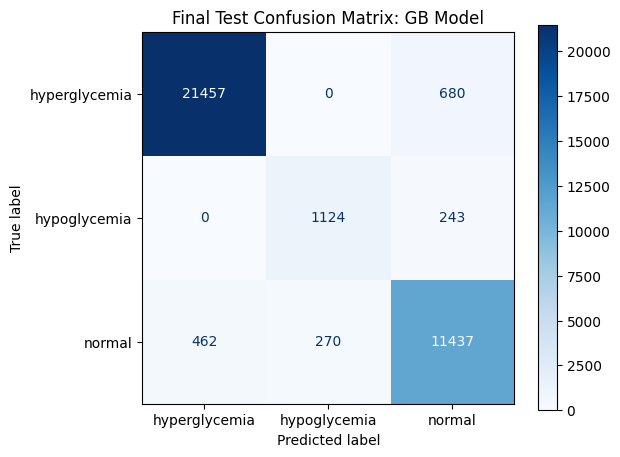

In [ ]:
# Overall metrics
unsafe_classes = label_encoder.transform(["hyperglycemia", "hypoglycemia"])

y_test_onset = y_test_encoded[onset_test]
y_pred_onset = y_test_pred[onset_test]
unsafe_mask = np.isin(y_test_onset, unsafe_classes)
correct_unsafe_onset = np.sum((y_test_onset == y_pred_onset) & unsafe_mask)
onset_accuracy = correct_unsafe_onset / len(y_test_onset)

test_result_gb = {
    "accuracy": accuracy_score(y_test_encoded, y_test_pred),
    "precision_macro": precision_score(y_test_encoded, y_test_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test_encoded, y_test_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test_encoded, y_test_pred, average="macro", zero_division=0),
    "precision_weighted": precision_score(y_test_encoded, y_test_pred, average="weighted", zero_division=0),
    "recall_weighted": recall_score(y_test_encoded, y_test_pred, average="weighted", zero_division=0),
    "f1_weighted": f1_score(y_test_encoded, y_test_pred, average="weighted", zero_division=0),
    "onset_accuracy": onset_accuracy
}

test_result_gb_df = pd.DataFrame([test_result_gb])

print("=================================================")
print("Final Test Result on GB Model")
print("=================================================")
display(test_result_gb_df)

print("=================================================")
print("Classification Report: GB Model")
print("=================================================")
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

# Confusion Matrix
cm_gb = confusion_matrix(y_test_encoded, y_test_pred)

cm_gb_df = pd.DataFrame(
    cm_gb,
    index=[f"true_{c}" for c in label_encoder.classes_],
    columns=[f"pred_{c}" for c in label_encoder.classes_]
)

print("=================================================")
print("Confusion Matrix: GB Model")
print("=================================================")
# display(cm_gb_df)

disp_gb = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6, 5))
disp_gb.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Final Test Confusion Matrix: GB Model")
plt.show()

## ⭐ Early Prediction on Onset

In [ ]:
# Create a DataFrame from test_feat_df for merging predictions
# This ensures that 'ID', 'timestamp', and 'glucose_category_predict' align correctly with the features used for prediction
predictions_for_merge_df = test_feat_df[['ID', 'timestamp']].copy()

y_pred_labels = label_encoder.inverse_transform(y_test_pred) # Convert numerical predictions back to string labels
predictions_for_merge_df['glucose_category_predict'] = y_pred_labels

# Ensure 'timestamp' in raw_test_df is in datetime format for merging
raw_test_df['timestamp'] = pd.to_datetime(raw_test_df['timestamp'])

# Merge the predictions back to the original raw_test_df
# Use a left merge to keep all rows from raw_test_df and add predictions where timestamps and IDs match
raw_test_pred_df = pd.merge(
    raw_test_df,
    predictions_for_merge_df,
    on=['ID', 'timestamp'],
    how='left'
)

# Display rows where 'onset' is True
display(raw_test_pred_df[raw_test_pred_df["onset"] == True])

,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,split,glucose_category_predict
609,canine1,canine1-001,2025-11-01 16:00:00,250.958497,hyperglycemia,True,False,True,False,test,hyperglycemia
685,canine1,canine1-001,2025-11-01 17:16:00,251.689776,hyperglycemia,True,False,True,False,test,normal
785,canine1,canine1-001,2025-11-01 18:56:00,250.028996,hyperglycemia,True,False,True,False,test,normal
1211,canine1,canine1-001,2025-11-02 02:02:00,254.584039,hyperglycemia,True,False,True,False,test,hyperglycemia
1314,canine1,canine1-001,2025-11-02 03:45:00,250.264759,hyperglycemia,True,False,True,False,test,normal
...,...,...,...,...,...,...,...,...,...,...,...
35704,canine1,canine1-021,2025-12-17 00:15:00,251.865622,hyperglycemia,True,False,True,False,test,hyperglycemia
35712,canine1,canine1-021,2025-12-17 00:23:00,259.978371,hyperglycemia,True,False,True,False,test,normal
36128,canine1,canine1-021,2025-12-17 07:19:00,250.134454,hyperglycemia,True,False,True,False,test,normal
36130,canine1,canine1-021,2025-12-17 07:21:00,251.713032,hyperglycemia,True,False,True,False,test,normal


In [ ]:
def display_onset_windows(df, window_size=15, onset_col="onset"):
    """
    Displays rows around each 'onset == True' event in the DataFrame.
    For each onset event, it shows `window_size` rows before and `window_size` rows after.
    """
    onset_indices = df[df[onset_col] == True].index.to_list()
    all_indices_to_display = set()

    for idx in onset_indices:
        start_idx = max(0, idx - window_size)
        end_idx = min(len(df) - 1, idx + window_size)
        for i in range(start_idx, end_idx + 1):
            all_indices_to_display.add(i)

    if not all_indices_to_display:
        print(f"No '{onset_col} == True' events found.")
        return

    # Sort the unique indices to maintain order
    sorted_indices = sorted(list(all_indices_to_display))

    # Display the collected rows
    display(df.loc[sorted_indices])


print("Displaying rows around 'onset == True' events in raw_test_pred_df:")
display_onset_windows(raw_test_pred_df, window_size=15)

Displaying rows around 'onset == True' events in raw_test_pred_df:


,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,split,glucose_category_predict
594,canine1,canine1-001,2025-11-01 15:45:00,255.953111,hyperglycemia,True,False,False,False,test,hyperglycemia
595,canine1,canine1-001,2025-11-01 15:46:00,253.450677,hyperglycemia,True,False,False,False,test,hyperglycemia
596,canine1,canine1-001,2025-11-01 15:47:00,250.692093,hyperglycemia,True,False,False,False,test,hyperglycemia
597,canine1,canine1-001,2025-11-01 15:48:00,248.016490,normal,False,False,False,False,test,hyperglycemia
598,canine1,canine1-001,2025-11-01 15:49:00,245.620286,normal,False,False,False,False,test,hyperglycemia
...,...,...,...,...,...,...,...,...,...,...,...
36474,canine1,canine1-021,2025-12-17 13:05:00,53.757496,hypoglycemia,True,False,False,False,test,normal
36475,canine1,canine1-021,2025-12-17 13:06:00,53.256571,hypoglycemia,True,False,False,False,test,normal
36476,canine1,canine1-021,2025-12-17 13:07:00,53.078501,hypoglycemia,True,False,False,False,test,normal
36477,canine1,canine1-021,2025-12-17 13:08:00,52.739847,hypoglycemia,True,False,False,False,test,normal


In [ ]:
display(raw_test_pred_df.head(50))

,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,split,glucose_category_predict
0,canine1,canine1-001,2025-11-01 05:51:00,375.000000,hyperglycemia,True,True,False,False,test,NaN
1,canine1,canine1-001,2025-11-01 05:52:00,375.056846,hyperglycemia,True,False,False,False,test,NaN
2,canine1,canine1-001,2025-11-01 05:53:00,374.714980,hyperglycemia,True,False,False,False,test,NaN
3,canine1,canine1-001,2025-11-01 05:54:00,375.045685,hyperglycemia,True,False,False,False,test,NaN
4,canine1,canine1-001,2025-11-01 05:55:00,375.676269,hyperglycemia,True,False,False,False,test,NaN
5,canine1,canine1-001,2025-11-01 05:56:00,374.153802,hyperglycemia,True,False,False,False,test,NaN
6,canine1,canine1-001,2025-11-01 05:57:00,373.098884,hyperglycemia,True,False,False,False,test,NaN
7,canine1,canine1-001,2025-11-01 05:58:00,373.424279,hyperglycemia,True,False,False,False,test,NaN
8,canine1,canine1-001,2025-11-01 05:59:00,373.378435,hyperglycemia,True,False,False,False,test,NaN
9,canine1,canine1-001,2025-11-01 06:00:00,373.667572,hyperglycemia,True,False,False,False,test,NaN


### Look into earlier 15mins

In [ ]:
def calculate_onset_early_prediction_accuracy(
    df,
    onset_col="onset",
    time_col="timestamp",
    actual_col="glucose_category",
    pred_col="glucose_category_predict",
    dog_col="dogID",
    segment_col="ID",
    lookback_minutes=15,
    event_classes=("hyperglycemia", "hypoglycemia"),
    include_onset_row=True,
    require_same_direction=True,
):
    """
    For each onset event, look back `lookback_minutes` within the same segment.

    If require_same_direction=True:
        - hyperglycemia onset must have a hyperglycemia prediction
        - hypoglycemia onset must have a hypoglycemia prediction

    If include_onset_row=True:
        the onset timestamp itself is included in the search window.
    """
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values([dog_col, segment_col, time_col]).reset_index(drop=True)

    onset_df = df[
        (df[onset_col] == True) &
        (df[actual_col].isin(event_classes))
    ].copy()

    results = []

    for _, onset_row in onset_df.iterrows():
        dog_id = onset_row[dog_col]
        seg_id = onset_row[segment_col]
        onset_time = onset_row[time_col]
        onset_class = onset_row[actual_col]

        window_start = onset_time - pd.Timedelta(minutes=lookback_minutes)

        if include_onset_row:
            mask_time = (df[time_col] >= window_start) & (df[time_col] <= onset_time)
        else:
            mask_time = (df[time_col] >= window_start) & (df[time_col] < onset_time)

        window_df = df[
            (df[dog_col] == dog_id) &
            (df[segment_col] == seg_id) &
            mask_time
        ].copy()

        if require_same_direction:
            success = (window_df[pred_col] == onset_class).any()
        else:
            success = window_df[pred_col].isin(event_classes).any()

        results.append({
            dog_col: dog_id,
            segment_col: seg_id,
            "onset_time": onset_time,
            "actual_onset_class": onset_class,
            "window_start": window_start,
            "window_end": onset_time,
            "n_rows_in_window": len(window_df),
            "success_early_prediction": bool(success),
            "preds_in_window": list(window_df[pred_col].dropna().unique()),
        })

    onset_eval_df = pd.DataFrame(results)
    onset_accuracy = (
        onset_eval_df["success_early_prediction"].mean()
        if len(onset_eval_df) > 0 else np.nan
    )

    return onset_eval_df, onset_accuracy

In [ ]:
onset_eval_df, onset_accuracy = calculate_onset_early_prediction_accuracy(
    df=raw_test_pred_df,
    onset_col="onset",
    time_col="timestamp",
    actual_col="glucose_category",
    pred_col="glucose_category_predict",
    dog_col="dogID",
    segment_col="ID",
    lookback_minutes=15,
    event_classes=("hyperglycemia", "hypoglycemia"),
    include_onset_row=True,
    require_same_direction=True
)

print("Early-onset prediction accuracy:", onset_accuracy)
display(onset_eval_df.head(100))

Early-onset prediction accuracy: 0.25555555555555554


,dogID,ID,onset_time,actual_onset_class,window_start,window_end,n_rows_in_window,success_early_prediction,preds_in_window
0,canine1,canine1-001,2025-11-01 16:00:00,hyperglycemia,2025-11-01 15:45:00,2025-11-01 16:00:00,16,True,[hyperglycemia]
1,canine1,canine1-001,2025-11-01 17:16:00,hyperglycemia,2025-11-01 17:01:00,2025-11-01 17:16:00,16,False,[normal]
2,canine1,canine1-001,2025-11-01 18:56:00,hyperglycemia,2025-11-01 18:41:00,2025-11-01 18:56:00,16,False,[normal]
3,canine1,canine1-001,2025-11-02 02:02:00,hyperglycemia,2025-11-02 01:47:00,2025-11-02 02:02:00,16,True,[hyperglycemia]
4,canine1,canine1-001,2025-11-02 03:45:00,hyperglycemia,2025-11-02 03:30:00,2025-11-02 03:45:00,16,True,"[hyperglycemia, normal]"
...,...,...,...,...,...,...,...,...,...
85,canine1,canine1-021,2025-12-17 00:15:00,hyperglycemia,2025-12-17 00:00:00,2025-12-17 00:15:00,16,True,"[normal, hyperglycemia]"
86,canine1,canine1-021,2025-12-17 00:23:00,hyperglycemia,2025-12-17 00:08:00,2025-12-17 00:23:00,16,True,"[hyperglycemia, normal]"
87,canine1,canine1-021,2025-12-17 07:19:00,hyperglycemia,2025-12-17 07:04:00,2025-12-17 07:19:00,16,False,[normal]
88,canine1,canine1-021,2025-12-17 07:21:00,hyperglycemia,2025-12-17 07:06:00,2025-12-17 07:21:00,16,False,[normal]


### Look into later 15mins

In [ ]:
def calculate_onset_accuracy_forward_window(
    df,
    time_col="timestamp",
    onset_col="onset",
    pred_col="glucose_category_predict",
    dog_col="dogID",
    segment_col="ID",
    horizon_minutes=15,
    unsafe_pred_classes=("hyperglycemia", "hypoglycemia"),
    include_current_row=True,
):
    """
    Onset-level accuracy with denominator = number of onset events.

    For each onset row at time T:
      - look at rows in [T, T+15] within the same dog and same segment
      - if ANY value in pred_col is unsafe (hyperglycemia / hypoglycemia),
        count that onset as successfully predicted early

    Returns:
      onset_eval_df: one row per onset event
      onset_accuracy: successful_onsets / total_onsets
    """
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values([dog_col, segment_col, time_col]).reset_index(drop=True)

    onset_df = df[df[onset_col] == True].copy()

    results = []

    for _, onset_row in onset_df.iterrows():
        dog_id = onset_row[dog_col]
        seg_id = onset_row[segment_col]
        onset_time = onset_row[time_col]

        window_end = onset_time + pd.Timedelta(minutes=horizon_minutes)

        if include_current_row:
            mask_time = (df[time_col] >= onset_time) & (df[time_col] <= window_end)
        else:
            mask_time = (df[time_col] > onset_time) & (df[time_col] <= window_end)

        window_df = df[
            (df[dog_col] == dog_id) &
            (df[segment_col] == seg_id) &
            mask_time
        ].copy()

        success = window_df[pred_col].isin(unsafe_pred_classes).any()

        results.append({
            dog_col: dog_id,
            segment_col: seg_id,
            "onset_time": onset_time,
            "window_end": window_end,
            "n_rows_in_window": len(window_df),
            "success_early_prediction": bool(success),
            "preds_in_window": list(window_df[pred_col].dropna().unique()),
        })

    onset_eval_df = pd.DataFrame(results)
    onset_accuracy = (
        onset_eval_df["success_early_prediction"].mean()
        if len(onset_eval_df) > 0 else np.nan
    )

    return onset_eval_df, onset_accuracy

In [ ]:
# Run it
onset_eval_df, onset_accuracy = calculate_onset_accuracy_forward_window(
    df=raw_test_pred_df,
    time_col="timestamp",
    onset_col="onset",
    pred_col="glucose_category_predict",
    dog_col="dogID",
    segment_col="ID",
    horizon_minutes=15,
    unsafe_pred_classes=("hyperglycemia", "hypoglycemia"),
    include_current_row=True
)

print("Onset accuracy:", onset_accuracy)
print("Number of onset events:", len(onset_eval_df))
display(onset_eval_df.head())

Onset accuracy: 0.34444444444444444
Number of onset events: 90


,dogID,ID,onset_time,window_end,n_rows_in_window,success_early_prediction,preds_in_window
0,canine1,canine1-001,2025-11-01 16:00:00,2025-11-01 16:15:00,16,True,"[hyperglycemia, normal]"
1,canine1,canine1-001,2025-11-01 17:16:00,2025-11-01 17:31:00,16,False,[normal]
2,canine1,canine1-001,2025-11-01 18:56:00,2025-11-01 19:11:00,16,False,[normal]
3,canine1,canine1-001,2025-11-02 02:02:00,2025-11-02 02:17:00,16,True,"[hyperglycemia, normal]"
4,canine1,canine1-001,2025-11-02 03:45:00,2025-11-02 04:00:00,16,False,[normal]


### two sided window

In [ ]:
def calculate_onset_accuracy_bidirectional_window(
    df,
    time_col="timestamp",
    onset_col="onset",
    pred_col="glucose_category_predict",
    dog_col="dogID",
    segment_col="ID",
    window_minutes=15,
    unsafe_pred_classes=("hyperglycemia", "hypoglycemia"),
    include_onset_row=True,
):
    """
    Onset-level accuracy with denominator = number of onset events.

    For each onset row at time T:
      - look at rows in [T-15, T+15] within the same dog and same segment
      - if ANY value in pred_col is unsafe (hyperglycemia / hypoglycemia),
        count that onset as successfully predicted

    Returns:
      onset_eval_df: one row per onset event
      onset_accuracy: successful_onsets / total_onsets
    """
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values([dog_col, segment_col, time_col]).reset_index(drop=True)

    onset_df = df[df[onset_col] == True].copy()

    results = []

    for _, onset_row in onset_df.iterrows():
        dog_id = onset_row[dog_col]
        seg_id = onset_row[segment_col]
        onset_time = onset_row[time_col]

        window_start = onset_time - pd.Timedelta(minutes=window_minutes)
        window_end = onset_time + pd.Timedelta(minutes=window_minutes)

        if include_onset_row:
            mask_time = (df[time_col] >= window_start) & (df[time_col] <= window_end)
        else:
            mask_time = (
                ((df[time_col] >= window_start) & (df[time_col] < onset_time)) |
                ((df[time_col] > onset_time) & (df[time_col] <= window_end))
            )

        window_df = df[
            (df[dog_col] == dog_id) &
            (df[segment_col] == seg_id) &
            mask_time
        ].copy()

        success = window_df[pred_col].isin(unsafe_pred_classes).any()

        results.append({
            dog_col: dog_id,
            segment_col: seg_id,
            "onset_time": onset_time,
            "window_start": window_start,
            "window_end": window_end,
            "n_rows_in_window": len(window_df),
            "success_prediction_in_window": bool(success),
            "preds_in_window": list(window_df[pred_col].dropna().unique()),
        })

    onset_eval_df = pd.DataFrame(results)
    onset_accuracy = (
        onset_eval_df["success_prediction_in_window"].mean()
        if len(onset_eval_df) > 0 else np.nan
    )

    return onset_eval_df, onset_accuracy

In [ ]:
# Run it
onset_eval_df_bi, onset_accuracy_bi = calculate_onset_accuracy_bidirectional_window(
    df=raw_test_pred_df,
    time_col="timestamp",
    onset_col="onset",
    pred_col="glucose_category_predict",
    dog_col="dogID",
    segment_col="ID",
    window_minutes=15,
    unsafe_pred_classes=("hyperglycemia", "hypoglycemia"),
    include_onset_row=True
)

print("Onset accuracy in [T-15, T+15]:", onset_accuracy_bi)
print("Number of onset events:", len(onset_eval_df_bi))
display(onset_eval_df_bi.head())

Onset accuracy in [T-15, T+15]: 0.3888888888888889
Number of onset events: 90


,dogID,ID,onset_time,window_start,window_end,n_rows_in_window,success_prediction_in_window,preds_in_window
0,canine1,canine1-001,2025-11-01 16:00:00,2025-11-01 15:45:00,2025-11-01 16:15:00,31,True,"[hyperglycemia, normal]"
1,canine1,canine1-001,2025-11-01 17:16:00,2025-11-01 17:01:00,2025-11-01 17:31:00,31,False,[normal]
2,canine1,canine1-001,2025-11-01 18:56:00,2025-11-01 18:41:00,2025-11-01 19:11:00,31,False,[normal]
3,canine1,canine1-001,2025-11-02 02:02:00,2025-11-02 01:47:00,2025-11-02 02:17:00,31,True,"[hyperglycemia, normal]"
4,canine1,canine1-001,2025-11-02 03:45:00,2025-11-02 03:30:00,2025-11-02 04:00:00,31,True,"[hyperglycemia, normal]"


In [ ]:
display(onset_eval_df_bi)

,dogID,ID,onset_time,window_start,window_end,n_rows_in_window,success_prediction_in_window,preds_in_window
0,canine1,canine1-001,2025-11-01 16:00:00,2025-11-01 15:45:00,2025-11-01 16:15:00,31,True,"[hyperglycemia, normal]"
1,canine1,canine1-001,2025-11-01 17:16:00,2025-11-01 17:01:00,2025-11-01 17:31:00,31,False,[normal]
2,canine1,canine1-001,2025-11-01 18:56:00,2025-11-01 18:41:00,2025-11-01 19:11:00,31,False,[normal]
3,canine1,canine1-001,2025-11-02 02:02:00,2025-11-02 01:47:00,2025-11-02 02:17:00,31,True,"[hyperglycemia, normal]"
4,canine1,canine1-001,2025-11-02 03:45:00,2025-11-02 03:30:00,2025-11-02 04:00:00,31,True,"[hyperglycemia, normal]"
...,...,...,...,...,...,...,...,...
85,canine1,canine1-021,2025-12-17 00:15:00,2025-12-17 00:00:00,2025-12-17 00:30:00,31,True,"[normal, hyperglycemia]"
86,canine1,canine1-021,2025-12-17 00:23:00,2025-12-17 00:08:00,2025-12-17 00:38:00,31,True,"[hyperglycemia, normal]"
87,canine1,canine1-021,2025-12-17 07:19:00,2025-12-17 07:04:00,2025-12-17 07:34:00,31,False,[normal]
88,canine1,canine1-021,2025-12-17 07:21:00,2025-12-17 07:06:00,2025-12-17 07:36:00,31,False,[normal]


Count # of onsets

In [ ]:
num_onset_true = raw_test_pred_df['onset'].sum()
print(f"Number of rows where onset is True in raw_test_pred_df: {num_onset_true}")

Number of rows where onset is True in raw_test_pred_df: 90


In [ ]:
num_onset_true = raw_train_df['onset'].sum()
print(f"Number of rows where onset is True in raw_train_df: {num_onset_true}")

Number of rows where onset is True in raw_train_df: 640


## ⭐ Feature Importance

Permutation importance on the final test set, which tells us what features matter most to the model - measuring the drop in *"f1_macro"* after shuffling each feature.

In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_model,
    X_test,
    y_test_encoded,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro"
)

perm_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

print("=================================================")
print("Permutation Importance (scoring = f1_macro)")
print("=================================================")
display(perm_importance_df)

Permutation Importance (scoring = f1_macro)


,feature,importance_mean,importance_std
4,last_glucose,0.567822,0.002608
0,mean_glucose,0.016761,0.000318
1,min_glucose,0.000000,0.000000
2,max_glucose,0.000000,0.000000
3,slope,0.000000,0.000000


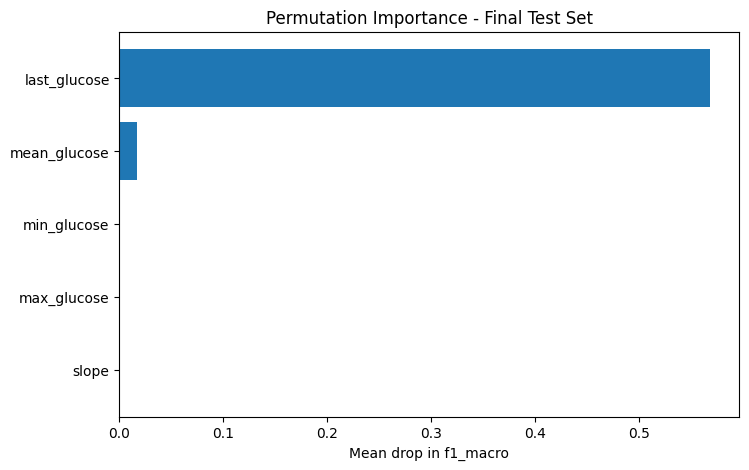

In [ ]:
# plot the importance
plt.figure(figsize=(8, 5))
plt.barh(perm_importance_df["feature"], perm_importance_df["importance_mean"])
plt.gca().invert_yaxis()
plt.xlabel("Mean drop in f1_macro")
plt.title("Permutation Importance - Final Test Set")
plt.show()

# 🔆 XGBoost

In [ ]:
# --------------------------------------------------
# Settings
# --------------------------------------------------
feature_cols = [
    "mean_glucose",
    "min_glucose",
    "max_glucose",
    "slope",
    "last_glucose"
]

target_col = "glucose_category"
group_col = "dogID"

X = train_feat_df[feature_cols]
y = train_feat_df[target_col]
groups = train_feat_df[group_col]
onset = train_feat_df["onset"]

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# unsafe class ids
unsafe_classes = label_encoder.transform(["hyperglycemia", "hypoglycemia"])

In [ ]:
# --------------------------------------------------
# LODO CV
# --------------------------------------------------
logo = LeaveOneGroupOut()

fold_results = []

for fold_idx, (tr_idx, val_idx) in enumerate(logo.split(X, y_encoded, groups=groups), start=1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y_encoded[tr_idx], y_encoded[val_idx]

    val_dog = groups.iloc[val_idx].iloc[0]

    model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(label_encoder.classes_),
        eval_metric="mlogloss",
        learning_rate=0.05,
        n_estimators=300,
        max_depth=6,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=1.0,
        reg_alpha=0.0,
        reg_lambda=1.0,
        tree_method="hist",
        random_state=42
    )

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    # --------------------------------------------------
    # Onset accuracy:
    # (correctly predicted unsafe class & onset==True) / total onset==True
    # --------------------------------------------------
    onset_val = onset.iloc[val_idx].astype(bool)

    y_val_onset = y_val[onset_val]
    y_pred_onset = y_pred[onset_val]


    unsafe_mask = np.isin(y_val_onset, unsafe_classes)
    correct_unsafe_onset = np.sum((y_val_onset == y_pred_onset) & unsafe_mask)
    onset_accuracy = correct_unsafe_onset / len(y_val_onset)


    # Output results
    fold_result = {
        "fold": fold_idx,
        "val_dog": val_dog,
        "n_val": len(y_val),
        "accuracy": accuracy_score(y_val, y_pred),
        "precision_macro": precision_score(y_val, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_val, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_val, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_val, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_val, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_val, y_pred, average="weighted", zero_division=0),
        "onset_accuracy": onset_accuracy
    }

    fold_results.append(fold_result)

print("=================================================")
print("LODO Result By Fold:")
print("=================================================")
lodo_results_df_xgboost = pd.DataFrame(fold_results)
display(lodo_results_df_xgboost)

# Output avg results
overall = {
    "accuracy": lodo_results_df_xgboost["accuracy"].mean(),
    "precision_macro": lodo_results_df_xgboost["precision_macro"].mean(),
    "recall_macro": lodo_results_df_xgboost["recall_macro"].mean(),
    "f1_macro": lodo_results_df_xgboost["f1_macro"].mean(),
    "precision_weighted": lodo_results_df_xgboost["precision_weighted"].mean(),
    "recall_weighted": lodo_results_df_xgboost["recall_weighted"].mean(),
    "f1_weighted": lodo_results_df_xgboost["f1_weighted"].mean(),
    "onset_accuracy": lodo_results_df_xgboost["onset_accuracy"].mean()
}

overall_df_xgboost = pd.DataFrame([overall])

print("=================================================")
print("LODO Overall Result - Average:")
print("=================================================")
display(overall_df_xgboost)

LODO Result By Fold:


,fold,val_dog,n_val,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,onset_accuracy
0,1,canine2,12867,0.920261,0.794994,0.644592,0.643442,0.906862,0.920261,0.904693,0.153846
1,2,canine3,60538,0.976197,0.646885,0.647270,0.647077,0.976578,0.976197,0.976386,0.227273
2,3,canine4,31471,0.967113,0.625410,0.634345,0.629756,0.967948,0.967113,0.967454,0.425926
3,4,canine5,69461,0.977671,0.688588,0.676002,0.680646,0.977406,0.977671,0.977522,0.193548
4,5,canine6,170426,0.966860,0.749378,0.708378,0.723034,0.966179,0.966860,0.966423,0.204819


LODO Overall Result - Average:


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,onset_accuracy
0,0.96162,0.701051,0.662117,0.664791,0.958995,0.96162,0.958496,0.241082


## ⭐ Tune Paramaters

Hyperparameters tuned using HalvingGridSearchCV:
   * "learning_rate"
   * "max_depth"
   * "min_child_weight"
   * "reg_alpha"
   * "reg_lambda"


In [ ]:
# --------------------------------------------------
# Parameter grid
# --------------------------------------------------
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 4, 6],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [0, 0.1, 1]
}

param_combinations = list(product(
    param_grid["n_estimators"],
    param_grid["learning_rate"],
    param_grid["max_depth"],
    param_grid["min_child_weight"],
    param_grid["reg_alpha"],
    param_grid["reg_lambda"]
))

print(f"Total parameter combinations: {len(param_combinations)}")

Total parameter combinations: 729


In [ ]:
# 1. Define the checkpoint path on your mounted Google Drive
checkpoint_path = '/content/drive/MyDrive/210 Capstone/final_data/xgb_tuning_checkpoint.csv'

# 2. Load existing results if they exist to support "Resume" functionality
if os.path.exists(checkpoint_path):
    existing_results_df = pd.read_csv(checkpoint_path)
    # Get the set of combo indices we have already finished
    finished_combos = set(existing_results_df['combo_idx'].unique())
    all_param_results = existing_results_df.to_dict('records')
    print(f"Checking Drive... Found existing progress. Skipping {len(finished_combos)} completed combinations.")
else:
    finished_combos = set()
    all_param_results = []
    print("No existing checkpoint found. Starting from Combo 1.")

# 3. The Tuning Loop
logo = LeaveOneGroupOut()

for combo_idx, (n_estimators, learning_rate, max_depth, min_child_weight, reg_alpha, reg_lambda) in enumerate(param_combinations, start=1):

    # RESUME LOGIC: Skip if this combo index is already in CSV
    if combo_idx in finished_combos:
        continue

    print("=" * 80)
    print(f"Running combo {combo_idx}/{len(param_combinations)} | "
          f"n_estimators={n_estimators}, lr={learning_rate}, max_depth={max_depth}")
    print("=" * 80)

    fold_results = []

    # LODO Cross-Validation
    for fold_idx, (tr_idx, val_idx) in enumerate(logo.split(X, y_encoded, groups=groups), start=1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y_encoded[tr_idx], y_encoded[val_idx]
        val_dog = groups.iloc[val_idx].iloc[0]

        model = XGBClassifier(
            objective="multi:softprob",
            num_class=len(label_encoder.classes_),
            eval_metric="mlogloss",
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_child_weight=min_child_weight,
            subsample=1.0,
            colsample_bytree=1.0,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            tree_method="hist",
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        # Onset Accuracy Calculation
        onset_val = onset.iloc[val_idx].astype(bool).to_numpy()
        y_val_onset = y_val[onset_val]
        y_pred_onset = y_pred[onset_val]
        unsafe_mask = np.isin(y_val_onset, unsafe_classes)
        correct_unsafe_onset = np.sum((y_val_onset == y_pred_onset) & unsafe_mask)
        onset_accuracy = correct_unsafe_onset / len(y_val_onset) if len(y_val_onset) > 0 else 0

        fold_results.append({
            "accuracy": accuracy_score(y_val, y_pred),
            "f1_macro": f1_score(y_val, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_val, y_pred, average="macro", zero_division=0),
            "onset_accuracy": onset_accuracy
        })

    # Average results for this parameter combination
    fold_df = pd.DataFrame(fold_results)
    param_result = {
        "combo_idx": combo_idx,
        "n_estimators": n_estimators,
        "learning_rate": learning_rate,
        "max_depth": max_depth,
        "min_child_weight": min_child_weight,
        "reg_alpha": reg_alpha,
        "reg_lambda": reg_lambda,
        "accuracy": fold_df["accuracy"].mean(),
        "f1_macro": fold_df["f1_macro"].mean(),
        "recall_macro": fold_df["recall_macro"].mean(),
        "onset_accuracy": fold_df["onset_accuracy"].mean()
    }

    all_param_results.append(param_result)

    # 4. AUTO-SAVE: Write to Drive every 5 combinations
    if combo_idx % 5 == 0:
        tuning_results_df = pd.DataFrame(all_param_results)
        tuning_results_df.to_csv(checkpoint_path, index=False)
        print(f"--- PROGRESS SAVED TO DRIVE: {len(all_param_results)} combos total ---")

# Final save after loop finishes
tuning_results_df = pd.DataFrame(all_param_results)
tuning_results_df.to_csv(checkpoint_path, index=False)

print("Tuning Complete! You can find the full results in your 'final_data' folder.")
display(tuning_results_df.sort_values(by="f1_macro", ascending=False).head(10))

Checking Drive... Found existing progress. Skipping 605 completed combinations.
Running combo 606/729 | n_estimators=300, lr=0.1, max_depth=4
Running combo 607/729 | n_estimators=300, lr=0.1, max_depth=4
Running combo 608/729 | n_estimators=300, lr=0.1, max_depth=4
Running combo 609/729 | n_estimators=300, lr=0.1, max_depth=4
Running combo 610/729 | n_estimators=300, lr=0.1, max_depth=4
--- PROGRESS SAVED TO DRIVE: 610 combos total ---
Running combo 611/729 | n_estimators=300, lr=0.1, max_depth=4
Running combo 612/729 | n_estimators=300, lr=0.1, max_depth=4
Running combo 613/729 | n_estimators=300, lr=0.1, max_depth=4
Running combo 614/729 | n_estimators=300, lr=0.1, max_depth=4
Running combo 615/729 | n_estimators=300, lr=0.1, max_depth=4
--- PROGRESS SAVED TO DRIVE: 615 combos total ---
Running combo 616/729 | n_estimators=300, lr=0.1, max_depth=4
Running combo 617/729 | n_estimators=300, lr=0.1, max_depth=4
Running combo 618/729 | n_estimators=300, lr=0.1, max_depth=4
Running combo 

,combo_idx,n_estimators,learning_rate,max_depth,min_child_weight,reg_alpha,reg_lambda,accuracy,f1_macro,recall_macro,onset_accuracy
710,711,300,0.2,6,1,1.0,1.0,0.960818,0.685607,0.681770,0.260743
405,406,200,0.2,2,1,0.0,0.0,0.960887,0.683889,0.676142,0.236886
707,708,300,0.2,6,1,0.1,1.0,0.960712,0.683357,0.679872,0.257499
162,163,100,0.2,2,1,0.0,0.0,0.960762,0.682979,0.674313,0.237371
408,409,200,0.2,2,1,0.1,0.0,0.960610,0.682833,0.675624,0.235327
467,468,200,0.2,6,1,1.0,1.0,0.960918,0.682001,0.678692,0.260288
464,465,200,0.2,6,1,0.1,1.0,0.961071,0.681525,0.675975,0.253302
719,720,300,0.2,6,3,1.0,1.0,0.960923,0.681517,0.676699,0.265514
476,477,200,0.2,6,3,1.0,1.0,0.961099,0.680692,0.676235,0.255094
714,715,300,0.2,6,3,0.1,0.0,0.960508,0.680620,0.676143,0.259459


In [ ]:
# # Comment out due to runtime session out
# # --------------------------------------------------
# # Parameter grid
# # --------------------------------------------------
# param_grid = {
#     "n_estimators": [100, 200, 300],
#     "learning_rate": [0.05, 0.1, 0.2],
#     "max_depth": [2, 4, 6],
#     "min_child_weight": [1, 3, 5],
#     "reg_alpha": [0, 0.1, 1],
#     "reg_lambda": [0, 0.1, 1]
# }

# param_combinations = list(product(
#     param_grid["n_estimators"],
#     param_grid["learning_rate"],
#     param_grid["max_depth"],
#     param_grid["min_child_weight"],
#     param_grid["reg_alpha"],
#     param_grid["reg_lambda"]
# ))

# print(f"Total parameter combinations: {len(param_combinations)}")

# # --------------------------------------------------
# # LODO tuning
# # --------------------------------------------------
# logo = LeaveOneGroupOut()

# all_fold_results = []
# all_param_results = []

# for combo_idx, (n_estimators, learning_rate, max_depth, min_child_weight, reg_alpha, reg_lambda) in enumerate(param_combinations, start=1):
#     print("=" * 80)
#     print(
#         f"Running combo {combo_idx}/{len(param_combinations)} | "
#         f"n_estimators={n_estimators}, "
#         f"learning_rate={learning_rate}, "
#         f"max_depth={max_depth}, "
#         f"min_child_weight={min_child_weight}, "
#         f"reg_alpha={reg_alpha}, "
#         f"reg_lambda={reg_lambda}"
#     )
#     print("=" * 80)

#     fold_results = []

#     for fold_idx, (tr_idx, val_idx) in enumerate(logo.split(X, y_encoded, groups=groups), start=1):
#         X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
#         y_tr, y_val = y_encoded[tr_idx], y_encoded[val_idx]

#         val_dog = groups.iloc[val_idx].iloc[0]

#         model = XGBClassifier(
#             objective="multi:softprob",
#             num_class=len(label_encoder.classes_),
#             eval_metric="mlogloss",
#             learning_rate=learning_rate,
#             n_estimators=n_estimators,
#             max_depth=max_depth,
#             min_child_weight=min_child_weight,
#             subsample=1.0,
#             colsample_bytree=1.0,
#             reg_alpha=reg_alpha,
#             reg_lambda=reg_lambda,
#             tree_method="hist",
#             random_state=42,
#             n_jobs=-1
#         )

#         model.fit(X_tr, y_tr)
#         y_pred = model.predict(X_val)

#         onset_val = onset.iloc[val_idx].astype(bool).to_numpy()
#         y_val_onset = y_val[onset_val]
#         y_pred_onset = y_pred[onset_val]

#         unsafe_mask = np.isin(y_val_onset, unsafe_classes)
#         correct_unsafe_onset = np.sum((y_val_onset == y_pred_onset) & unsafe_mask)
#         onset_accuracy = correct_unsafe_onset / len(y_val_onset)

#         fold_result = {
#             "combo_idx": combo_idx,
#             "fold": fold_idx,
#             "val_dog": val_dog,
#             "n_val": len(y_val),
#             "n_estimators": n_estimators,
#             "learning_rate": learning_rate,
#             "max_depth": max_depth,
#             "min_child_weight": min_child_weight,
#             "reg_alpha": reg_alpha,
#             "reg_lambda": reg_lambda,
#             "accuracy": accuracy_score(y_val, y_pred),
#             "precision_macro": precision_score(y_val, y_pred, average="macro", zero_division=0),
#             "recall_macro": recall_score(y_val, y_pred, average="macro", zero_division=0),
#             "f1_macro": f1_score(y_val, y_pred, average="macro", zero_division=0),
#             "precision_weighted": precision_score(y_val, y_pred, average="weighted", zero_division=0),
#             "recall_weighted": recall_score(y_val, y_pred, average="weighted", zero_division=0),
#             "f1_weighted": f1_score(y_val, y_pred, average="weighted", zero_division=0),
#             "onset_accuracy": onset_accuracy
#         }

#         fold_results.append(fold_result)
#         all_fold_results.append(fold_result)

#     fold_df = pd.DataFrame(fold_results)

#     param_result = {
#         "combo_idx": combo_idx,
#         "n_estimators": n_estimators,
#         "learning_rate": learning_rate,
#         "max_depth": max_depth,
#         "min_child_weight": min_child_weight,
#         "reg_alpha": reg_alpha,
#         "reg_lambda": reg_lambda,
#         "accuracy": fold_df["accuracy"].mean(),
#         "precision_macro": fold_df["precision_macro"].mean(),
#         "recall_macro": fold_df["recall_macro"].mean(),
#         "f1_macro": fold_df["f1_macro"].mean(),
#         "precision_weighted": fold_df["precision_weighted"].mean(),
#         "recall_weighted": fold_df["recall_weighted"].mean(),
#         "f1_weighted": fold_df["f1_weighted"].mean(),
#         "onset_accuracy": fold_df["onset_accuracy"].mean()
#     }

#     all_param_results.append(param_result)

# # --------------------------------------------------
# # Results tables
# # --------------------------------------------------
# all_fold_results_df = pd.DataFrame(all_fold_results)
# tuning_results_df = pd.DataFrame(all_param_results)

# print("======================================================")
# print("Tuning Results - All Parameter Combinations - XGBoost")
# print("======================================================")
# display(tuning_results_df.sort_values(
#     by=["accuracy", "recall_macro", "f1_macro"],
#     ascending=False
# ).reset_index(drop=True))


Total parameter combinations: 729
Running combo 1/729 | n_estimators=100, learning_rate=0.05, max_depth=2, min_child_weight=1, reg_alpha=0, reg_lambda=0
Running combo 2/729 | n_estimators=100, learning_rate=0.05, max_depth=2, min_child_weight=1, reg_alpha=0, reg_lambda=0.1
Running combo 3/729 | n_estimators=100, learning_rate=0.05, max_depth=2, min_child_weight=1, reg_alpha=0, reg_lambda=1
Running combo 4/729 | n_estimators=100, learning_rate=0.05, max_depth=2, min_child_weight=1, reg_alpha=0.1, reg_lambda=0
Running combo 5/729 | n_estimators=100, learning_rate=0.05, max_depth=2, min_child_weight=1, reg_alpha=0.1, reg_lambda=0.1
Running combo 6/729 | n_estimators=100, learning_rate=0.05, max_depth=2, min_child_weight=1, reg_alpha=0.1, reg_lambda=1
Running combo 7/729 | n_estimators=100, learning_rate=0.05, max_depth=2, min_child_weight=1, reg_alpha=1, reg_lambda=0
Running combo 8/729 | n_estimators=100, learning_rate=0.05, max_depth=2, min_child_weight=1, reg_alpha=1, reg_lambda=0.1
Ru

In [ ]:
# Add a combined_score column to see the best parameters
tuning_results_df["combined_score"] = (
    0.3 * tuning_results_df["f1_macro"] +
    0.1 * tuning_results_df["recall_macro"] +
    0.6 * tuning_results_df["accuracy"]
)

top5_combined_xg = (
    tuning_results_df
    .sort_values(by="combined_score", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

display(top5_combined_xg)

,combo_idx,n_estimators,learning_rate,max_depth,min_child_weight,reg_alpha,reg_lambda,accuracy,f1_macro,recall_macro,onset_accuracy,combined_score
0,711,300,0.2,6,1,1.0,1.0,0.960818,0.685607,0.681770,0.260743,0.850350
1,708,300,0.2,6,1,0.1,1.0,0.960712,0.683357,0.679872,0.257499,0.849421
2,406,200,0.2,2,1,0.0,0.0,0.960887,0.683889,0.676142,0.236886,0.849313
3,468,200,0.2,6,1,1.0,1.0,0.960918,0.682001,0.678692,0.260288,0.849021
4,163,100,0.2,2,1,0.0,0.0,0.960762,0.682979,0.674313,0.237371,0.848782


In [ ]:
print("=================================================")
print("Best Parameter Combination - XGBoost")
print("=================================================")
best_params_row_xg = tuning_results_df.sort_values(
    by=["accuracy", "f1_macro", "recall_macro"],
    ascending=False
).iloc[0]

display(pd.DataFrame([best_params_row_xg]))

Best Parameter Combination - XGBoost


,combo_idx,n_estimators,learning_rate,max_depth,min_child_weight,reg_alpha,reg_lambda,accuracy,f1_macro,recall_macro,onset_accuracy,combined_score
236,237.0,100.0,0.2,6.0,5.0,0.0,1.0,0.961962,0.673424,0.667115,0.236796,0.845916


## ⭐ Best Model

In [ ]:
# Final model with best params

final_model_xg = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    max_depth=6,
    min_child_weight=1,
    learning_rate=0.2,
    n_estimators=300,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=1.0,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=42
)

final_model_xg.fit(X, y_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=3, ...)

## ⭐ Model Test

Final Test Result - XGBoost


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,onset_accuracy
0,0.94144,0.868006,0.765007,0.797726,0.938093,0.94144,0.937486,0.269663


Classification Report - XGBoost
               precision    recall  f1-score   support

hyperglycemia       0.97      0.98      0.98     22137
 hypoglycemia       0.73      0.38      0.50      1367
       normal       0.90      0.93      0.92     12169

     accuracy                           0.94     35673
    macro avg       0.87      0.77      0.80     35673
 weighted avg       0.94      0.94      0.94     35673

Confusion Matrix - XGBoost


,hyperglycemia,hypoglycemia,normal
hyperglycemia,21686,0,451
hypoglycemia,0,520,847
normal,602,189,11378


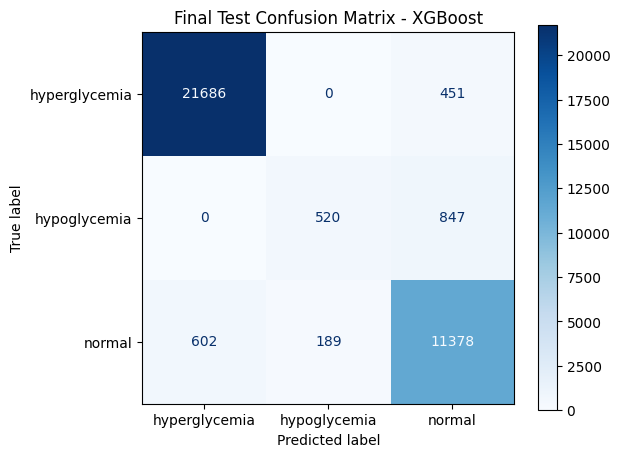

In [ ]:
# Prepare test data
X_test = test_feat_df[feature_cols]
y_test = test_feat_df[target_col]
onset_test = test_feat_df["onset"].astype(bool)

# Predict on test set
y_test_pred = final_model_xg.predict(X_test)

# --------------------------------------------------------------------
# Onset accuracy on test set
# (correctly predicted unsafe class & onset==True) / total onset==True
# --------------------------------------------------------------------
onset_test_mask = onset_test.astype(bool)

y_test_onset = y_test_encoded[onset_test_mask]
y_pred_onset = y_test_pred[onset_test_mask]

unsafe_mask = np.isin(y_test_onset, unsafe_classes)
correct_unsafe_onset = np.sum((y_test_onset == y_pred_onset) & unsafe_mask)
onset_accuracy = correct_unsafe_onset / len(y_test_onset)


# --------------------------------------------------
# Metrics
# --------------------------------------------------
test_result_xg = {
    "accuracy": accuracy_score(y_test_encoded, y_test_pred),
    "precision_macro": precision_score(y_test_encoded, y_test_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test_encoded, y_test_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test_encoded, y_test_pred, average="macro", zero_division=0),
    "precision_weighted": precision_score(y_test_encoded, y_test_pred, average="weighted", zero_division=0),
    "recall_weighted": recall_score(y_test_encoded, y_test_pred, average="weighted", zero_division=0),
    "f1_weighted": f1_score(y_test_encoded, y_test_pred, average="weighted", zero_division=0),
    "onset_accuracy": onset_accuracy
}

test_result_xg_df = pd.DataFrame([test_result_xg])

print("=================================================")
print("Final Test Result - XGBoost")
print("=================================================")
display(test_result_xg_df)

print("=================================================")
print("Classification Report - XGBoost")
print("=================================================")
print(classification_report(
    y_test_encoded,
    y_test_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

print("=================================================")
print("Confusion Matrix - XGBoost")
print("=================================================")
cm_xg = confusion_matrix(y_test_encoded, y_test_pred)
cm_xg_df = pd.DataFrame(cm_xg, index=label_encoder.classes_, columns=label_encoder.classes_)
display(cm_xg_df)

# Plot the confusion matrix
disp_xg = ConfusionMatrixDisplay(
    confusion_matrix=cm_xg,
    display_labels=label_encoder.classes_
)
fig, ax = plt.subplots(figsize=(6, 5))
disp_xg.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Final Test Confusion Matrix - XGBoost")
plt.show()